### 1.Import Libraties

In [1]:
import pandas as pd
import psycopg2

### 2.Connect PostgreSQL

In [2]:
conn = psycopg2.connect(
    database ="healthcare_db",
    user = "postgres",
    password = "Rohan@2003",
    host = "localhost",
    port = "5432"
)

query = "Select * from hospital_management"
df = pd.read_sql(query,conn)

print(df.head())

C:\Users\rohan\AppData\Local\Temp\ipykernel_1180\1770975723.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


  patient_id  age  gender            city    disease admission_date region  \
0     P00006   54  Female  Stoke-on-Trent   Diabetes     2021-04-15  South   
1     P00007   84  Female  Stoke-on-Trent   Fracture     2021-10-05   West   
2     P00284   36    Male        Langford       COPD     2022-11-06   West   
3     P00406   68    Male          oxford     Sepsis     2022-05-27   West   
4     P00746   45  Female          oxford  Influenza     2022-12-30   West   

   department  treatment_cost insurance_type payment_status        feedback  \
0  Othopadics          274.48      Uninsured     Debit Card     Fully Agree   
1     Surgery          274.48       Medicare     Debit Card     Fully Agree   
2          OT           36.33      Uninsured    Net Banking     Fully Agree   
3  Othopadics            5.63       Medicare    Net Banking     Fully Agree   
4          OT           11.50      Uninsured    Credit Card  Fully Disagree   

  treatment_outcome  rating  
0         Discharge     5.

### 3.Python EDA

In [3]:
import matplotlib.pyplot as plt

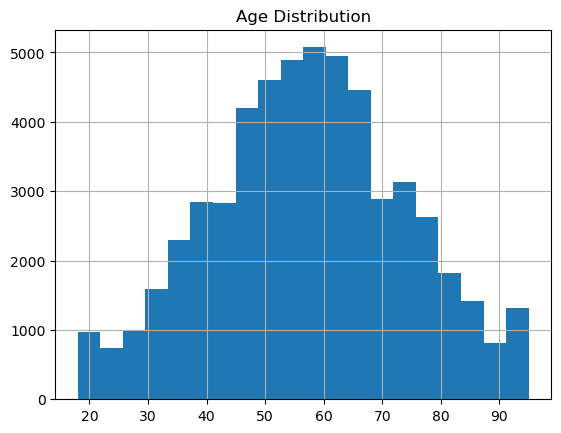

In [6]:
df['age'].hist(bins=20)
plt.title("Age Distribution")
plt.show()

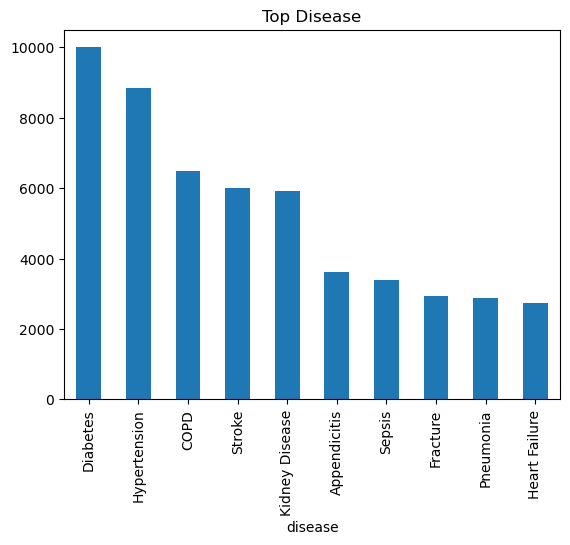

In [7]:
df['disease'].value_counts().head(10).plot(kind='bar')
plt.title("Top Disease")
plt.show()

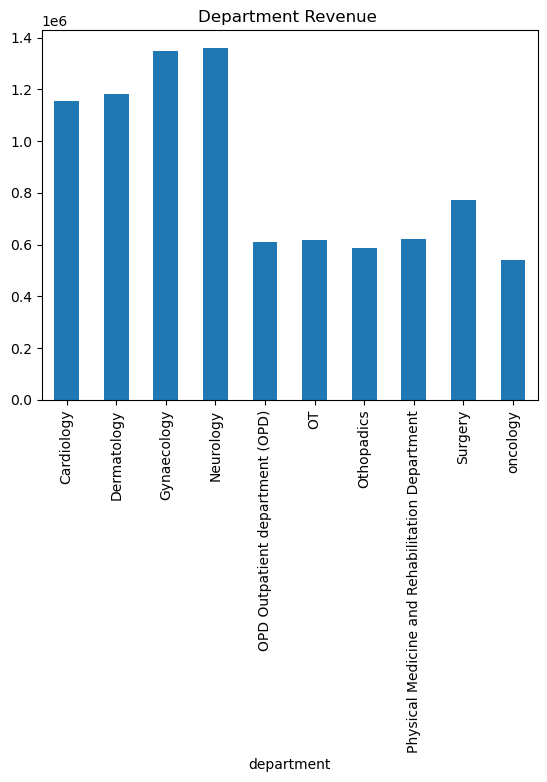

In [10]:
df.groupby('department')['treatment_cost'].sum().plot(kind='bar')
plt.title("Department Revenue ")
plt.show()

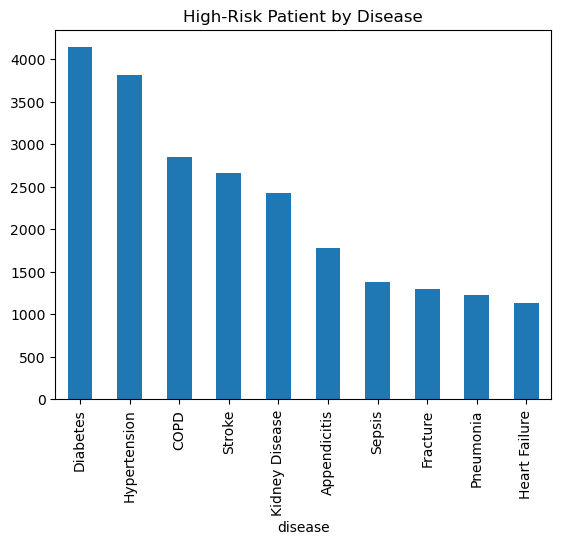

In [14]:
high_risk = df[df['age'] > 60]

risk_by_disease = high_risk['disease'].value_counts().head(10)
risk_by_disease.plot(kind='bar')
plt.title('High-Risk Patient by Disease')
plt.show()

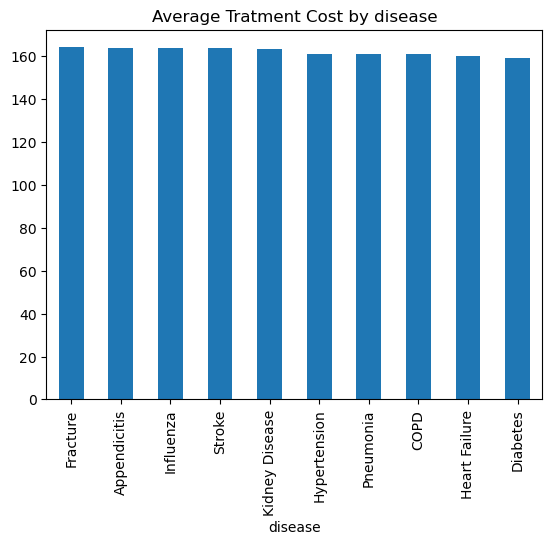

In [17]:
avg_cost = df.groupby('disease')['treatment_cost'].mean().sort_values(ascending=False).head(10)

avg_cost.plot(kind='bar')
plt.title("Average Tratment Cost by disease")
plt.show()

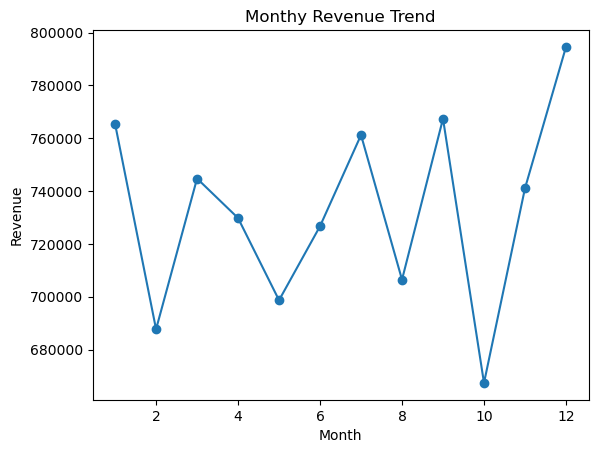

In [19]:
df['admission_date'] = pd.to_datetime(df['admission_date'])

monthy_revenue = df.groupby(df['admission_date'].dt.month)['treatment_cost'].sum()

monthy_revenue.plot(marker='o')
plt.title("Monthy Revenue Trend")
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [12]:
df['risk_level'] = df['age'].apply(
    lambda x:'High Risk' if x > 60 else 'Normal'
)

print(df['risk_level'].value_counts())

risk_level
Normal       31020
High Risk    23403
Name: count, dtype: int64


In [13]:
df['risk_level'] = (
    (df['age']>60) &
    (df['treatment_cost']) > 50000
)

### 4.Export Processed Data

In [20]:
df.to_csv("healthcare_processed.csv",index=False)